Carregando dados do SBHAR...
Shape X_train: (7233, 125, 6)
Shape X_val:   (801, 125, 6)
Shape X_test:  (3275, 125, 6)
Número de classes ativas: 12

Calculando pesos de classes para proteger as transições posturais...

--- Pré-computando Imagens URP (Isto levará alguns minutos, mas acelerará o treino) ---


Gerando matrizes URP: 100%|██████████| 3275/3275 [00:03<00:00, 865.79it/s]



--- INICIANDO EXPERIMENTO 1: Base + Class Weights ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.4619 - loss: 1.5989 - val_accuracy: 0.7740 - val_loss: 0.7775 - learning_rate: 1.0000e-04
Epoch 2/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.7474 - loss: 0.9220 - val_accuracy: 0.8265 - val_loss: 0.5897 - learning_rate: 1.0000e-04
Epoch 3/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8344 - loss: 0.5842 - val_accuracy: 0.8727 - val_loss: 0.4022 - learning_rate: 1.0000e-04
Epoch 4/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8749 - loss: 0.4179 - val_accuracy: 0.8876 - val_loss: 0.3716 - learning_rate: 1.0000e-04
Epoch 5/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9119 - loss: 0.3102 - val_accuracy: 0.8976 - val_loss: 0.2957 - learning_rate: 1.0000e-04
Epoch 6/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9343 - loss: 0.1925 - val_accuracy: 0.8

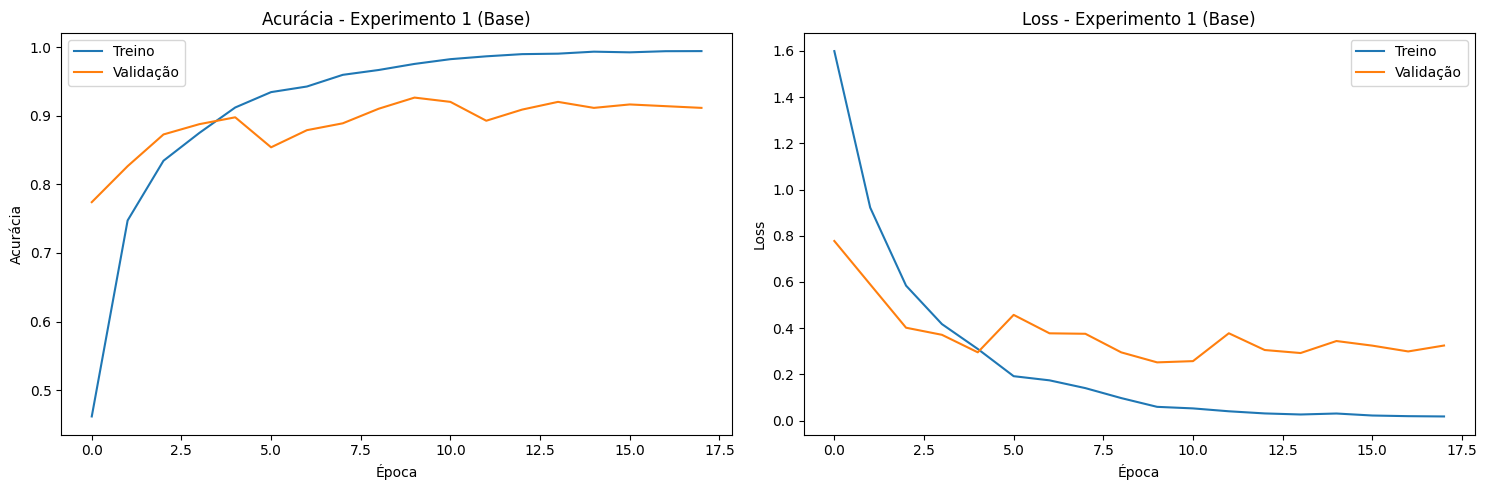


Gerando previsões no conjunto de teste...
103/103 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.86      0.73      0.79       507
           2       0.93      0.96      0.94       491
           3       0.74      0.86      0.80       438
           4       0.87      0.85      0.86       522
           5       0.87      0.93      0.90       575
           6       1.00      0.93      0.97       567
           7       0.74      0.54      0.62        26
           8       0.83      1.00      0.91        10
           9       0.57      0.76      0.65        33
          10       0.71      0.58      0.64        26
          11       0.67      0.54      0.60        52
          12       0.56      0.71      0.62        28

    accuracy                           0.87      3275
   macro avg       0.78      0.78      0.77      3275
weighted avg       0.87      0.87      0.87      3275



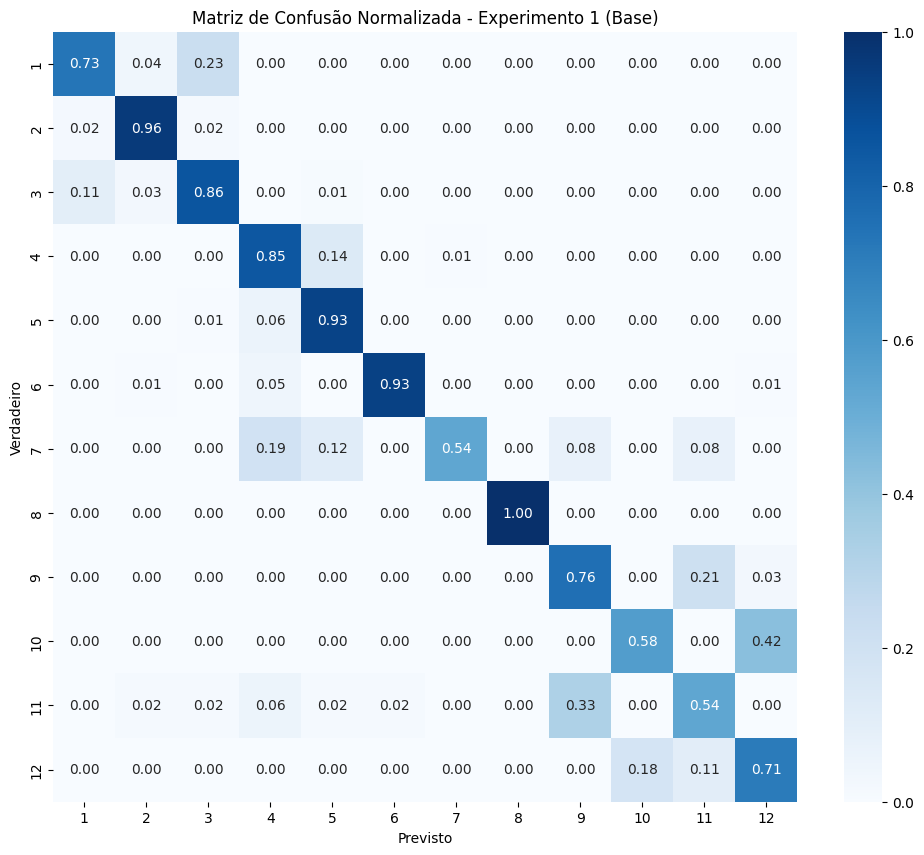


Calculando métricas via Bootstrap (1000 iterações)...

>>> Acurácia (Média ± Desvio Padrão): 0.8658 ± 0.0060
>>> F1-Score Ponderado (Média ± Desvio): 0.8656 ± 0.0060



In [1]:
# ==========================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==========================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm

# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)

# ==========================================
# 2. CARREGAMENTO DOS DADOS (.npz)
# ==========================================
DATA_PATH = "/content/sbhar_for_rp.npz"

print("Carregando dados do SBHAR...")
data = np.load(DATA_PATH)

# Carregando os dados já particionados
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

# Nomes originais das classes salvos durante o pre-processamento
classes = data['classes']
num_classes = len(classes)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_val:   {X_val.shape}")
print(f"Shape X_test:  {X_test.shape}")
print(f"Número de classes ativas: {num_classes}")

# ==========================================
# 3. BALANCEAMENTO DE CLASSES
# ==========================================
print("\nCalculando pesos de classes para proteger as transições posturais...")
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}

TETO_MAXIMO = 8.0
for k in class_weights_dict.keys():
    if class_weights_dict[k] > TETO_MAXIMO:
        class_weights_dict[k] = TETO_MAXIMO

# ==========================================
# 4. PRÉ-PROCESSAMENTO URP E TF.DATA PIPELINE
# ==========================================
idx_x = [0, 3] # acc_x, gyro_x
idx_y = [1, 4] # acc_y, gyro_y
idx_z = [2, 5] # acc_z, gyro_z

def generate_urp_images(X_1d, target_img_size=(112, 112)):
    """Pré-computa as imagens URP para evitar gargalo de CPU durante o treinamento."""
    N = len(X_1d)
    X_img = np.zeros((N, target_img_size[0], target_img_size[1], 3), dtype=np.float32)

    for i in tqdm(range(N), desc="Gerando matrizes URP"):
        window = X_1d[i]
        dist_r = squareform(pdist(window[:, idx_x], metric='euclidean'))
        dist_g = squareform(pdist(window[:, idx_y], metric='euclidean'))
        dist_b = squareform(pdist(window[:, idx_z], metric='euclidean'))

        img = np.stack([dist_r, dist_g, dist_b], axis=-1)
        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)

        img = (1.0 - img) ** 3
        img_255 = (img * 255.0).astype(np.float32)
        img_resized = cv2.resize(img_255, target_img_size, interpolation=cv2.INTER_LINEAR)
        X_img[i] = applications.resnet50.preprocess_input(img_resized)

    return X_img

print("\n--- Pré-computando Imagens URP (Isto levará alguns minutos, mas acelerará o treino) ---")
X_train_img = generate_urp_images(X_train)
X_val_img = generate_urp_images(X_val)
X_test_img = generate_urp_images(X_test)

# Construindo tf.data.Datasets eficientes em memória
batch_size = 32

train_gen = tf.data.Dataset.from_tensor_slices(((X_train_img, X_train), y_train)) \
    .shuffle(buffer_size=2048) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_gen = tf.data.Dataset.from_tensor_slices(((X_val_img, X_val), y_val)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

test_gen = tf.data.Dataset.from_tensor_slices(((X_test_img, X_test), y_test)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

y_true_test = y_test
target_names = [str(c) for c in classes]

# ==========================================
# 5. FUNÇÃO DE AVALIAÇÃO UNIFICADA
# ==========================================
def run_evaluation(model, history, test_ds, y_true, target_names, exp_name="Experimento"):
    print(f"\n{'='*60}\n--- RESULTADOS: {exp_name.upper()} ---\n{'='*60}")

    # A. Curva de Aprendizado
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(history.history['accuracy'], label='Treino')
    axes[0].plot(history.history['val_accuracy'], label='Validação')
    axes[0].set_title(f'Acurácia - {exp_name}')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Acurácia')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Treino')
    axes[1].plot(history.history['val_loss'], label='Validação')
    axes[1].set_title(f'Loss - {exp_name}')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # B. Previsões e Classification Report
    print("\nGerando previsões no conjunto de teste...")
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # C. Matriz de Confusão Normalizada
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Matriz de Confusão Normalizada - {exp_name}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()

    # D. Bootstrap para Acurácia e F1-Score
    print("\nCalculando métricas via Bootstrap (1000 iterações)...")
    n_iterations = 1000
    n_size = len(y_true)
    acc_scores = []
    f1_scores = []

    for i in range(n_iterations):
        idx = resample(np.arange(n_size), n_samples=n_size)
        y_true_boot = y_true[idx]
        y_pred_boot = y_pred[idx]

        acc_scores.append(accuracy_score(y_true_boot, y_pred_boot))
        f1_scores.append(f1_score(y_true_boot, y_pred_boot, average='weighted'))

    print(f"\n>>> Acurácia (Média ± Desvio Padrão): {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
    print(f">>> F1-Score Ponderado (Média ± Desvio): {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}\n")

# ==========================================
# 6. CONSTRUÇÃO DO MODELO LATE FUSION (EXP 1)
# ==========================================
def build_sbhar_late_fusion(num_classes, num_features=6, window_size=128):
    input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img")
    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(128, activation='relu')(x_img)
    x_img = layers.Dropout(0.3)(x_img)

    input_1d = layers.Input(shape=(window_size, num_features), name="input_1d_series")
    x_1d = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Flatten()(x_1d)
    x_1d = layers.Dense(64, activation='relu')(x_1d)

    merged = layers.concatenate([x_img, x_1d])
    z = layers.Dense(128, activation='relu')(merged)
    z = layers.Dropout(0.4)(z)
    output = layers.Dense(num_classes, activation='softmax', name="output_class")(z)

    return models.Model(inputs=[input_img, input_1d], outputs=output)

# ==========================================
# 7. TREINAMENTO E AVALIAÇÃO (EXP 1)
# ==========================================
print("\n--- INICIANDO EXPERIMENTO 1: Base + Class Weights ---")
model_exp1 = build_sbhar_late_fusion(num_classes=num_classes, window_size=125)
model_exp1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history_exp1 = model_exp1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

run_evaluation(model_exp1, history_exp1, test_gen, y_true_test, target_names, exp_name="Experimento 1 (Base)")

103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


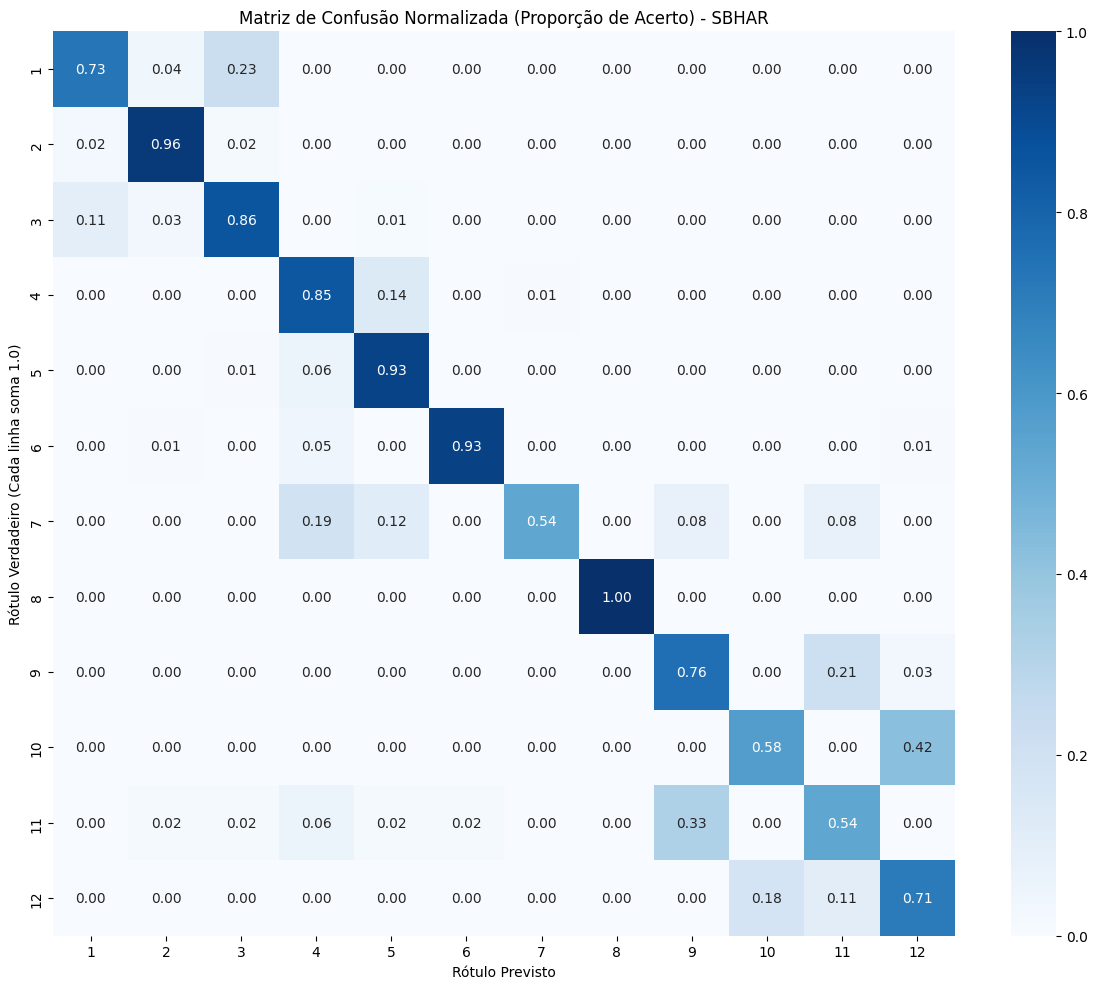

In [2]:
# ==========================================
# Plot da Matriz de Confusão Normalizada
# ==========================================

# 1. Primeiro, geramos as previsões do modelo no conjunto de teste
y_pred_probs = model_exp1.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Configuramos a figura
plt.figure(figsize=(12, 10))

# 3. Calculamos a matriz usando y_test (os rótulos reais) e y_pred
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# Plota o Heatmap usando fmt='.2f' para mostrar os valores proporcionais (ex: 0.95 = 95%)
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',       # Exibe 2 casas decimais
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    vmin=0.0,        # Fixa o mínimo da escala de cor em 0
    vmax=1.0         # Fixa o máximo da escala de cor em 1 (100%)
)

plt.title('Matriz de Confusão Normalizada (Proporção de Acerto) - SBHAR')
plt.ylabel('Rótulo Verdadeiro (Cada linha soma 1.0)')
plt.xlabel('Rótulo Previsto')

plt.tight_layout()
plt.show()

### EXPERIMENTO 2: Otimização de Hiperparâmetros com Optuna

Nesta seção, vamos utilizar o framework Optuna para buscar os melhores hiperparâmetros para a nossa rede Late Fusion.

In [3]:
!pip install optuna
!pip install optuna optuna-integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 5.5 MB/s eta 0:00:00


In [4]:
import optuna
from optuna_integration import TFKerasPruningCallback
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks

In [5]:
# ==========================================
# FUNÇÃO OBJETIVO PARA O OPTUNA
# ==========================================
def objective(trial):
    # 1. Definição do Espaço de Busca (Search Space)
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    dropout_rate_img = trial.suggest_float('dropout_rate_img', 0.2, 0.6)
    dropout_rate_z = trial.suggest_float('dropout_rate_z', 0.3, 0.7)
    dense_units_1d = trial.suggest_categorical('dense_units_1d', [32, 64, 128])
    dense_units_fusion = trial.suggest_categorical('dense_units_fusion', [64, 128, 256])

    # --- Ramo 1: ResNet50 ---
    input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img_opt")
    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(128, activation='relu')(x_img)
    x_img = layers.Dropout(dropout_rate_img)(x_img)

    # --- Ramo 2: CNN 1D ---
    input_1d = layers.Input(shape=(125, 6), name="input_1d_series_opt")
    x_1d = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Flatten()(x_1d)
    x_1d = layers.Dense(dense_units_1d, activation='relu')(x_1d)

    # --- Fusão ---
    merged = layers.concatenate([x_img, x_1d])
    z = layers.Dense(dense_units_fusion, activation='relu')(merged)
    z = layers.Dropout(dropout_rate_z)(z)
    output = layers.Dense(num_classes, activation='softmax', name="output_class_opt")(z)

    model_opt = models.Model(inputs=[input_img, input_1d], outputs=output)

    # 2. Compilação do Modelo
    model_opt.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 3. Callbacks para Otimização (Pruning e EarlyStopping curto)
    early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    pruning_callback = TFKerasPruningCallback(trial, 'val_accuracy')

    # 4. Treinamento
    # Vamos usar poucas épocas (ex: 15) para permitir que o Optuna teste várias combinações rápido
    history = model_opt.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        class_weight=class_weights_dict,
        callbacks=[early_stopping, pruning_callback],
        verbose=0 # Silenciando o output para não poluir o log
    )

    # A métrica que queremos MAXIMIZAR é a acurácia de validação
    best_val_acc = max(history.history['val_accuracy'])
    return best_val_acc

# ==========================================
# INICIALIZAÇÃO DO ESTUDO OPTUNA
# ==========================================
print("\n--- Iniciando a Otimização de Hiperparâmetros (Optuna) ---")
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=3)
)

# Rodando 10 tentativas (trials) como teste inicial.
# Você pode aumentar para 30-50 para uma busca mais profunda.
study.optimize(objective, n_trials=10)

print("\n=== RESULTADO DA OTIMIZAÇÃO ===")
print(f"Melhor Acurácia de Validação: {study.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


[I 2026-04-27 13:23:46,394] A new study created in memory with name: no-name-b53ff8d4-c7d4-48bf-b4b3-8120fd4bc8e4



--- Iniciando a Otimização de Hiperparâmetros (Optuna) ---


[I 2026-04-27 13:26:52,716] Trial 0 finished with value: 0.9176030158996582 and parameters: {'learning_rate': 1.3144692893487068e-05, 'dropout_rate_img': 0.4927668955074969, 'dropout_rate_z': 0.30881637972919745, 'dense_units_1d': 128, 'dense_units_fusion': 256}. Best is trial 0 with value: 0.9176030158996582.
[I 2026-04-27 13:29:10,316] Trial 1 finished with value: 0.898876428604126 and parameters: {'learning_rate': 8.366221085827092e-05, 'dropout_rate_img': 0.5040085373240247, 'dropout_rate_z': 0.6522210752361096, 'dense_units_1d': 64, 'dense_units_fusion': 256}. Best is trial 0 with value: 0.9176030158996582.
[I 2026-04-27 13:31:07,036] Trial 2 finished with value: 0.9500623941421509 and parameters: {'learning_rate': 0.00026476673817349536, 'dropout_rate_img': 0.4900004356458229, 'dropout_rate_z': 0.5103650218074024, 'dense_units_1d': 32, 'dense_units_fusion': 256}. Best is trial 2 with value: 0.9500623941421509.
[I 2026-04-27 13:32:18,052] Trial 3 pruned. Trial was pruned at epoch 


=== RESULTADO DA OTIMIZAÇÃO ===
Melhor Acurácia de Validação: 0.9501
Melhores Hiperparâmetros encontrados:
  learning_rate: 0.00026476673817349536
  dropout_rate_img: 0.4900004356458229
  dropout_rate_z: 0.5103650218074024
  dense_units_1d: 32
  dense_units_fusion: 256


### EXPERIMENTO 2 (Final): Treinamento com os Melhores Hiperparâmetros

In [6]:
# ==========================================
# TREINAMENTO DO MODELO OTIMIZADO
# ==========================================
best_params = study.best_params

# --- Ramo 1: ResNet50 ---
input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img_final")
base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
for layer in base_resnet.layers[:-15]:
    layer.trainable = False

x_img = base_resnet.output
x_img = layers.GlobalAveragePooling2D()(x_img)
x_img = layers.Dense(128, activation='relu')(x_img)
x_img = layers.Dropout(best_params['dropout_rate_img'])(x_img)

# --- Ramo 2: CNN 1D ---
input_1d = layers.Input(shape=(125, 6), name="input_1d_series_final")
x_1d = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_1d)
x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x_1d)
x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
x_1d = layers.Flatten()(x_1d)
x_1d = layers.Dense(best_params['dense_units_1d'], activation='relu')(x_1d)

# --- Fusão ---
merged = layers.concatenate([x_img, x_1d])
z = layers.Dense(best_params['dense_units_fusion'], activation='relu')(merged)
z = layers.Dropout(best_params['dropout_rate_z'])(z)
output = layers.Dense(num_classes, activation='softmax', name="output_class_final")(z)

model_exp2 = models.Model(inputs=[input_img, input_1d], outputs=output)

model_exp2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

print("Treinando o modelo final do Experimento 2...")
history_exp2 = model_exp2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Avaliação padrão usando a função existente (opcional, apenas para os gráficos básicos)
# run_evaluation(model_exp2, history_exp2, test_gen, y_true_test, target_names, exp_name="Experimento 2 (Optuna)")


Treinando o modelo final do Experimento 2...
Epoch 1/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.4735 - loss: 1.5343 - val_accuracy: 0.7690 - val_loss: 0.7402 - learning_rate: 2.6477e-04
Epoch 2/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.7503 - loss: 0.8462 - val_accuracy: 0.8514 - val_loss: 0.4524 - learning_rate: 2.6477e-04
Epoch 3/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8436 - loss: 0.5999 - val_accuracy: 0.9051 - val_loss: 0.2899 - learning_rate: 2.6477e-04
Epoch 4/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8876 - loss: 0.4684 - val_accuracy: 0.8976 - val_loss: 0.3205 - learning_rate: 2.6477e-04
Epoch 5/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9096 - loss: 0.3911 - val_accuracy: 0.8864 - val_loss: 0.3275 - learning_rate: 2.6477e-04
Epoch 6/40
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9324 - loss: 0.2991 - val_accuracy: 0.8939 - val_loss: 0.3086 - learning_rate: 2.6477e-04
Epoch 7/

### Tabela Comparativa e Histograma (Exp 1 vs Exp 2)

Calculando métricas para Experimento 1...
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Calculando métricas para Experimento 2...
103/103 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step

=== TABELA COMPARATIVA ===


,Experimento,Mean Accuracy,Mean F1-Score
0,Exp 1 (Base),0.865311,0.865140
1,Exp 2 (Otimizado),0.876267,0.876839


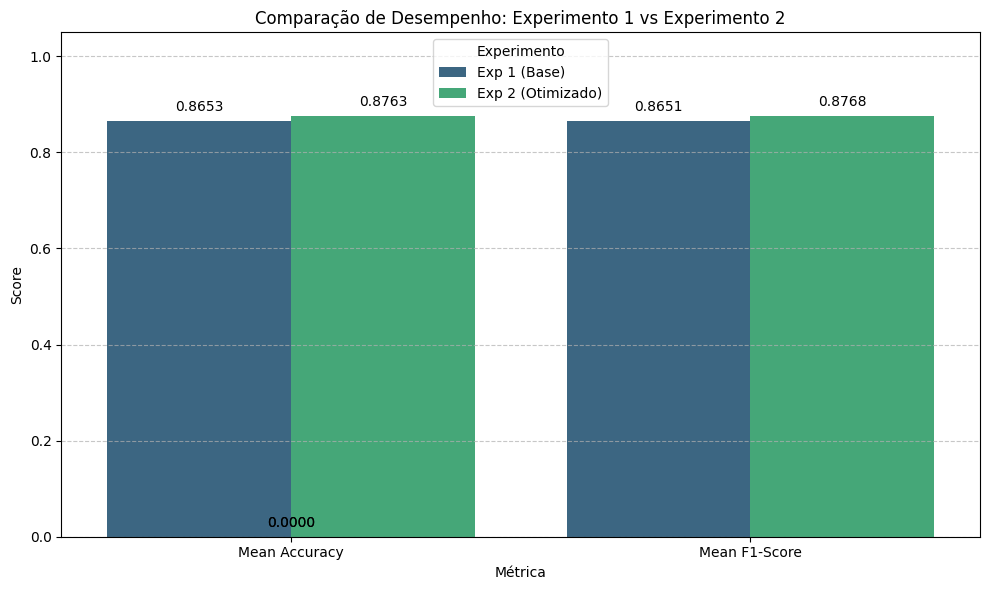

In [7]:
import pandas as pd

def calculate_bootstrap_metrics(model, test_ds, y_true, n_iterations=1000):
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    n_size = len(y_true)
    acc_scores = []
    f1_scores = []

    for i in range(n_iterations):
        idx = resample(np.arange(n_size), n_samples=n_size)
        y_true_boot = y_true[idx]
        y_pred_boot = y_pred[idx]

        acc_scores.append(accuracy_score(y_true_boot, y_pred_boot))
        f1_scores.append(f1_score(y_true_boot, y_pred_boot, average='weighted'))

    return np.mean(acc_scores), np.mean(f1_scores)

print("Calculando métricas para Experimento 1...")
mean_acc_exp1, mean_f1_exp1 = calculate_bootstrap_metrics(model_exp1, test_gen, y_true_test, n_iterations=500)

print("Calculando métricas para Experimento 2...")
mean_acc_exp2, mean_f1_exp2 = calculate_bootstrap_metrics(model_exp2, test_gen, y_true_test, n_iterations=500)

# 1. Tabela Comparativa
results_df = pd.DataFrame({
    'Experimento': ['Exp 1 (Base)', 'Exp 2 (Otimizado)'],
    'Mean Accuracy': [mean_acc_exp1, mean_acc_exp2],
    'Mean F1-Score': [mean_f1_exp1, mean_f1_exp2]
})

print("\n=== TABELA COMPARATIVA ===")
display(results_df)

# 2. Histograma Comparativo
results_melted = results_df.melt(id_vars='Experimento', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(10, 6))
sns.barplot(x='Métrica', y='Valor', hue='Experimento', data=results_melted, palette='viridis')
plt.title('Comparação de Desempenho: Experimento 1 vs Experimento 2')
plt.ylim(0.0, 1.05)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando os valores em cima das barras
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()
